# Selección de numero de generaciones

In [47]:
# importaciones
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import json
import random
import os
import time as _time
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# ==========================================
# 1. RECUPERAR ARTEFACTOS Y CONFIGURACIÓN
# ==========================================
ARTIFACTS_DIR = "../../models/artifacts"

# 1.1 Cargar la configuración del modelo ganador
print(f"\U0001f4c2 Leyendo configuración desde {ARTIFACTS_DIR}/model_config.json...")
with open(f"{ARTIFACTS_DIR}/model_config.json", "r") as f:
    config = json.load(f)

# Extraer parámetros clave
INPUT_SIZE = config["input_size"]
OUTPUT_SIZE = config["output_size"]
NUM_LAYERS = config["num_layers"]
NEURONS = config["neurons"]
ACTIVATION = config["activation"]
FEATURES_ORDER = config["features_in_order"]
TARGETS_ORDER = config["targets_in_order"]

print(f"\u2705 Configuración cargada: MLP {INPUT_SIZE} -> {NUM_LAYERS} capas de {NEURONS} neuronas -> {OUTPUT_SIZE}")
print(f"\U0001f4cb Orden obligatorio de features: {FEATURES_ORDER}")

# 1.2 Reconstruir la Clase del Modelo
class DynamicMLP(nn.Module):
    """Red Neuronal Multicapa que se construye al vuelo según los hiperparámetros."""
    def __init__(self, input_size, output_size, num_layers, neurons, activation):
        super(DynamicMLP, self).__init__()
        layers = []
        in_features = input_size
        act_fn = nn.ReLU() if activation == 'ReLU' else nn.Tanh()

        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, neurons))
            layers.append(act_fn)
            in_features = neurons
            
        layers.append(nn.Linear(in_features, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# 1.3 Instanciar modelo y cargar pesos
model = DynamicMLP(INPUT_SIZE, OUTPUT_SIZE, NUM_LAYERS, NEURONS, ACTIVATION)
try:
    model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_predictor.pt"))
    model.eval()
    print("\u2705 Pesos del modelo cargados correctamente.")
except Exception as e:
    print(f"\u274c Error cargando pesos: {e}")

# 1.4 Cargar Escaladores
scaler_X = joblib.load(f"{ARTIFACTS_DIR}/scaler_X.pkl")
scaler_y = joblib.load(f"{ARTIFACTS_DIR}/scaler_y.pkl")
print("\u2705 Escaladores (X e y) cargados.")

📂 Leyendo configuración desde ../../models/artifacts/model_config.json...
✅ Configuración cargada: MLP 5 -> 4 capas de 32 neuronas -> 2
📋 Orden obligatorio de features: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
✅ Pesos del modelo cargados correctamente.
✅ Escaladores (X e y) cargados.


C:\Users\vgarc\AppData\Local\Temp\ipykernel_11188\1142813354.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_pred

## definición del problema de optimización uni-objetivo con restricción

En estas celdas se configura el algoritmo genético utilizado posteriormente en `optimization_ga_v4`. El objetivo de este cuaderno no es construir la tabla completa de setpoints, sino estudiar cuántas generaciones son necesarias para que el optimizador alcance una solución estable en una muestra representativa de escenarios.

La optimización se plantea sobre dos variables de decisión:

- `F_flow`: caudal de leche tratado por la bomba.
- `T_servicio`: temperatura del fluido de servicio térmico.

Las condiciones externas no controlables se consideran fijas para cada escenario:

- `T_in_leche`: temperatura de entrada de la leche.
- `t_ciclo`: tiempo transcurrido desde la última limpieza CIP.
- `Delta_P`: caída de presión, utilizada como indicador indirecto del estado de ensuciamiento.

La función de predicción utiliza el modelo MLP entrenado previamente para estimar:

- `E_consumo`: consumo energético estimado.
- `T_out_leche`: temperatura de salida de la leche.

La función de fitness es uni-objetivo:

\[
\min \frac{E_{consumo}}{F_{flow}}
\]

sujeta a la restricción operacional:

\[
T_{out\_leche} \geq 72.3^\circ C
\]

Si la solución no cumple la restricción térmica, se aplica una penalización al fitness. De esta forma, el algoritmo no trabaja con un frente de Pareto, sino con un único valor escalar que representa el consumo específico penalizado.

La arquitectura evaluada en este cuaderno debe ser equivalente a la usada en `optimization_ga_v4`:

- `FitnessMin_v4`, con `weights=(-1.0,)`.
- selección por torneo (`selTournament`).
- cruce `cxBlend`.
- mutación `mutGaussian`.
- evolución personalizada con `varOr`.
- selección sobre padres e hijos.
- conservación del mejor individuo mediante `HallOfFame(1)`.

In [49]:
# ==========================================
# FUNCIÓN DE PREDICCIÓN Y FITNESS UNI-OBJETIVO
# (min E/F — consumo específico, con restricción T_out >= 72.3°C)
# ==========================================

BOUNDS = {
    'F_flow':     (3500.0, 5500.0),
    'T_servicio': (76.0,   95.0),
}

T_OUT_MIN = 72.3
PENALTY_FACTOR = 10.0


def predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P):
    """
    Envoltorio del modelo MLP: dado un escenario operativo completo,
    devuelve (E_consumo, T_out_leche) en unidades reales.
    """
    x_raw = np.array([[T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P]])
    x_scaled = scaler_X.transform(x_raw)
    x_tensor = torch.FloatTensor(x_scaled)

    with torch.no_grad():
        y_scaled = model(x_tensor).numpy()

    y_real = scaler_y.inverse_transform(y_scaled)[0]

    return y_real[0], y_real[1]


def fitness_consumo_especifico(individual, T_in_leche, t_ciclo, Delta_P):
    """
    Fitness uni-objetivo equivalente al usado en optimization_ga_v4.

    Objetivo:
        minimizar E_consumo / F_flow

    Restricción:
        T_out_leche >= 72.3 °C
    """
    F_flow, T_servicio = individual

    E_consumo, T_out = predict_with_model(
        F_flow,
        T_servicio,
        T_in_leche,
        t_ciclo,
        Delta_P
    )

    if T_out < T_OUT_MIN:
        deficit = T_OUT_MIN - T_out
        penalty = 1.0 + PENALTY_FACTOR * deficit

        penalized_value = 10000.0 + (
            float(E_consumo) / max(float(F_flow), 1.0)
        ) * penalty

        return (penalized_value,)

    consumo_especifico = float(E_consumo) / max(float(F_flow), 1.0)

    return (consumo_especifico,)


print("Funciones de predicción y fitness uni-objetivo definidas.")
print(f"   Espacio de búsqueda: F_flow in {BOUNDS['F_flow']}, T_servicio in {BOUNDS['T_servicio']}")
print("   Objetivo único: min E/F")
print(f"   Restricción penalizada: T_out_leche >= {T_OUT_MIN} °C")
print(f"   Factor de penalización: {PENALTY_FACTOR}")

Funciones de predicción y fitness uni-objetivo definidas.
   Espacio de búsqueda: F_flow in (3500.0, 5500.0), T_servicio in (76.0, 95.0)
   Objetivo único: min E/F
   Restricción penalizada: T_out_leche >= 72.3 °C
   Factor de penalización: 10.0


In [50]:
# ==========================================
# CONFIGURACIÓN DE GA UNI-OBJETIVO (DEAP)
# ==========================================

for cls_name in ["FitnessMin_v4", "Individual_v4"]:
    if cls_name in creator.__dict__:
        del creator.__dict__[cls_name]

creator.create("FitnessMin_v4", base.Fitness, weights=(-1.0,))
creator.create("Individual_v4", list, fitness=creator.FitnessMin_v4)

toolbox = base.Toolbox()

toolbox.register("attr_F_flow", random.uniform, BOUNDS['F_flow'][0], BOUNDS['F_flow'][1])
toolbox.register("attr_T_servicio", random.uniform, BOUNDS['T_servicio'][0], BOUNDS['T_servicio'][1])

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual_v4,
    (toolbox.attr_F_flow, toolbox.attr_T_servicio),
    n=1
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

LOW = [BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]]
UP = [BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]]


def checkBounds(low, up):
    def decorator(func):
        def wrapper(*args, **kw):
            offspring = func(*args, **kw)

            for child in offspring:
                for i, (lo, hi) in enumerate(zip(low, up)):
                    child[i] = max(lo, min(hi, child[i]))

            return offspring
        return wrapper
    return decorator


toolbox.decorate("mate", checkBounds(LOW, UP))
toolbox.decorate("mutate", checkBounds(LOW, UP))

GA_OPT = {
    'pop_size': 150,
    'n_gen': 15,
    'cxpb': 0.8,
    'mutpb': 0.2,
}

print("Toolbox DEAP configurada para GA uni-objetivo.")
print(f"   Población: {GA_OPT['pop_size']}")
print(f"   Generaciones producción: {GA_OPT['n_gen']}")
print(f"   P(cruce): {GA_OPT['cxpb']}")
print(f"   P(mutación): {GA_OPT['mutpb']}")
print("   Selección: selTournament, tournsize=3")
print("   Cruce: cxBlend, alpha=0.5")
print("   Mutación: mutGaussian, sigma=0.2, indpb=0.2")
print("   Arquitectura: custom varOr + selTournament + HallOfFame")

Toolbox DEAP configurada para GA uni-objetivo.
   Población: 150
   Generaciones producción: 15
   P(cruce): 0.8
   P(mutación): 0.2
   Selección: selTournament, tournsize=3
   Cruce: cxBlend, alpha=0.5
   Mutación: mutGaussian, sigma=0.2, indpb=0.2
   Arquitectura: custom varOr + selTournament + HallOfFame


## ejecución del ga uni-objetivo en un escenario base

Antes de ejecutar el análisis de convergencia sobre 100 escenarios, se comprueba el comportamiento del optimizador en un escenario representativo.

Se fijan las siguientes condiciones externas:

- `T_in_leche = 4.0 °C`
- `t_ciclo = 300 min`
- `Delta_P = 0.65 bar`

Para este escenario, el algoritmo genético busca los valores óptimos de:

- `F_flow`
- `T_servicio`

El criterio de optimización es minimizar el consumo específico:

\[
\frac{E_{consumo}}{F_{flow}}
\]

manteniendo la restricción:

\[
T_{out\_leche} \geq 72.3^\circ C
\]

A diferencia de la versión anterior basada en NSGA-II, aquí no se calcula un frente de Pareto. El resultado del proceso evolutivo es un único individuo óptimo, almacenado en `HallOfFame(1)`.

In [51]:
# ==========================================
# EJECUCIÓN DEL GA UNI-OBJETIVO -- ESCENARIO BASE
# Arquitectura equivalente a optimization_ga_v4
# ==========================================

SCENARIO = {
    'T_in_leche': 4.0,
    't_ciclo': 300,
    'Delta_P': 0.65,
}

toolbox.register(
    "evaluate",
    fitness_consumo_especifico,
    T_in_leche=SCENARIO['T_in_leche'],
    t_ciclo=SCENARIO['t_ciclo'],
    Delta_P=SCENARIO['Delta_P']
)

random.seed(1)
np.random.seed(1)

pop = toolbox.population(n=GA_OPT['pop_size'])

# Evaluar población inicial
fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

# Logbook y Hall of Fame
logbook = tools.Logbook()
hof = tools.HallOfFame(1)
hof.update(pop)

print("=" * 70)
print("EJECUCIÓN DEL GA UNI-OBJETIVO EN ESCENARIO BASE")
print("=" * 70)
print(f"T_in_leche: {SCENARIO['T_in_leche']} °C")
print(f"t_ciclo:    {SCENARIO['t_ciclo']} min")
print(f"Delta_P:    {SCENARIO['Delta_P']} bar")
print("-" * 70)
print("Objetivo:    min E_consumo / F_flow")
print(f"Restricción: T_out_leche >= {T_OUT_MIN} °C")
print("Algoritmo:   custom varOr + selTournament + HallOfFame")
print("-" * 70)

t_start = _time.time()

for gen in range(GA_OPT['n_gen']):

    offspring = algorithms.varOr(
        pop,
        toolbox,
        lambda_=len(pop),
        cxpb=GA_OPT['cxpb'],
        mutpb=GA_OPT['mutpb']
    )

    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = list(map(toolbox.evaluate, invalid_ind))

    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    pop[:] = toolbox.select(pop + offspring, len(pop))

    hof.update(pop)

    fits = [ind.fitness.values[0] for ind in pop]

    logbook.record(
        gen=gen,
        min=min(fits),
        max=max(fits),
        avg=np.mean(fits)
    )

t_elapsed = _time.time() - t_start

best_ind = hof[0]
best_F_flow, best_T_servicio = best_ind

best_E, best_T_out = predict_with_model(
    best_F_flow,
    best_T_servicio,
    SCENARIO['T_in_leche'],
    SCENARIO['t_ciclo'],
    SCENARIO['Delta_P']
)

best_E = float(best_E)
best_T_out = float(best_T_out)
best_F_flow = float(best_F_flow)
best_T_servicio = float(best_T_servicio)

best_consumo_esp = best_E / max(best_F_flow, 1.0)
t_out_status = "OK" if best_T_out >= T_OUT_MIN else "VIOLA RESTRICCIÓN"

print("=" * 70)
print("SOLUCIÓN SELECCIONADA")
print("=" * 70)
print(f"F_flow*          = {best_F_flow:.2f} L/h")
print(f"T_servicio*      = {best_T_servicio:.2f} °C")
print(f"E_consumo        = {best_E:.2f} kW")
print(f"T_out_leche      = {best_T_out:.2f} °C [{t_out_status}]")
print(f"Consumo espec.   = {best_consumo_esp:.6f} kW/(L/h)")
print(f"Fitness final    = {best_ind.fitness.values[0]:.6f}")
print(f"Tiempo ejecución = {t_elapsed:.2f} s")
print("=" * 70)

EJECUCIÓN DEL GA UNI-OBJETIVO EN ESCENARIO BASE
T_in_leche: 4.0 °C
t_ciclo:    300 min
Delta_P:    0.65 bar
----------------------------------------------------------------------
Objetivo:    min E_consumo / F_flow
Restricción: T_out_leche >= 72.3 °C
Algoritmo:   custom varOr + selTournament + HallOfFame
----------------------------------------------------------------------
SOLUCIÓN SELECCIONADA
F_flow*          = 5500.00 L/h
T_servicio*      = 80.86 °C
E_consumo        = 378.44 kW
T_out_leche      = 72.30 °C [OK]
Consumo espec.   = 0.068807 kW/(L/h)
Fitness final    = 0.068807
Tiempo ejecución = 0.83 s


# planteamiento específico del problema

A diferencia de una optimización aislada sobre un único escenario, el sistema final debe proporcionar setpoints para múltiples combinaciones de condiciones externas no controlables.

En este caso se consideran tres variables externas:

- temperatura de entrada de la leche (`T_in_leche`);
- caída de presión (`Delta_P`);
- tiempo desde la última limpieza CIP (`t_ciclo`).

Para cada combinación de estas variables, el algoritmo debe optimizar dos variables de control:

- caudal de proceso (`F_flow`);
- temperatura de servicio (`T_servicio`).

Ejecutar el algoritmo genético durante demasiadas generaciones para cada escenario puede incrementar innecesariamente el tiempo de cálculo de la tabla de recomendaciones. Por ello, este cuaderno estudia la convergencia del optimizador en una muestra reducida de 100 escenarios.

La finalidad es estimar un número de generaciones suficientemente conservador para usarlo después en la generación masiva de la lookup table de `optimization_ga_v4`.

# selección del número de generaciones

Se ejecuta el GA uni-objetivo sobre una malla reducida de 100 escenarios, formada por:

- 4 valores de `T_in_leche`;
- 5 valores de `Delta_P`;
- 5 valores de `t_ciclo`.

Para cada escenario se registra:

- generación estimada de convergencia;
- tiempo de ejecución;
- mejor fitness alcanzado;
- consumo específico de la mejor solución;
- setpoints óptimos obtenidos;
- factibilidad térmica de la solución.

El criterio de parada temprana se basa en la ausencia de mejora del mejor individuo global durante un número fijo de generaciones (`PATIENCE`). El mejor individuo global se obtiene mediante `HallOfFame(1)`, igual que en `optimization_ga_v4`.

In [52]:
# ==============================================================================
# CELDA 1: ANÁLISIS DE CONVERGENCIA V4
# BÚSQUEDA DE GENERACIONES CLAVE CON EARLY STOPPING
# Arquitectura equivalente a optimization_ga_v4:
#   fitness_consumo_especifico + FitnessMin_v4 + selTournament
#   varOr(lambda_=len(pop)) + HallOfFame
# ==============================================================================

import itertools
import time
import numpy as np
import pandas as pd
from deap import tools, algorithms

# ------------------------------------------------------------------------------
# 1. Malla reducida de escenarios
# ------------------------------------------------------------------------------
# Se mantiene una muestra de 100 escenarios, pero usando el dominio de v4:
# - T_in_leche: 4 valores
# - Delta_P: 5 valores dentro del rango usado en optimization_ga_v4
# - t_ciclo: 5 valores hasta 800 min
#
# Total = 4 x 5 x 5 = 100 escenarios

T_in_vals = [2.0, 4.0, 6.0, 8.0]
Delta_P_vals = [0.4, 0.5, 0.6, 0.8, 1.0]
t_ciclo_vals = [0, 200, 400, 600, 800]

escenarios = list(itertools.product(T_in_vals, Delta_P_vals, t_ciclo_vals))

# ------------------------------------------------------------------------------
# 2. Configuración del análisis de convergencia
# ------------------------------------------------------------------------------
# MAX_GEN_TEST debe ser superior al n_gen definitivo usado en producción.
# Aquí buscamos cuántas generaciones son suficientes antes de fijar n_gen.

MAX_GEN_TEST = 80
PATIENCE = 10
TOLERANCIA = 1e-3

MASTER_SEED = 1

resultados_convergencia = []

print("=" * 80)
print("ANÁLISIS DE CONVERGENCIA V4")
print("=" * 80)
print(f"Escenarios evaluados: {len(escenarios)}")
print("Arquitectura evaluada:")
print("   Fitness:       min E_consumo / F_flow")
print("   Selección:     selTournament, tournsize=3")
print("   Cruce:         cxBlend, alpha=0.5")
print("   Mutación:      mutGaussian, sigma=0.2, indpb=0.2")
print("   Evolución:     custom varOr + selección sobre padres+hijos")
print("   Elitismo:      HallOfFame(1)")
print(f"   Población:     {GA_OPT['pop_size']}")
print(f"   MAX_GEN_TEST:  {MAX_GEN_TEST}")
print(f"   Patience:      {PATIENCE}")
print(f"   Tolerancia:    {TOLERANCIA}")
print("=" * 80)

start_total = time.time()

for idx, (t_in, dp, t_ciclo) in enumerate(escenarios):

    # --------------------------------------------------------------------------
    # 3. Semilla reproducible por escenario
    # --------------------------------------------------------------------------
    seed = MASTER_SEED + idx
    random.seed(seed)
    np.random.seed(seed)

    # --------------------------------------------------------------------------
    # 4. Registrar fitness para el escenario actual
    # --------------------------------------------------------------------------
    toolbox.register(
        "evaluate",
        fitness_consumo_especifico,
        T_in_leche=float(t_in),
        t_ciclo=int(t_ciclo),
        Delta_P=float(dp)
    )

    # --------------------------------------------------------------------------
    # 5. Inicializar y evaluar población
    # --------------------------------------------------------------------------
    pop = toolbox.population(n=GA_OPT['pop_size'])

    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    # --------------------------------------------------------------------------
    # 6. Hall of Fame, equivalente a optimization_ga_v4
    # --------------------------------------------------------------------------
    hof = tools.HallOfFame(1)
    hof.update(pop)

    # Mejor histórico inicial
    mejor_historico = float(hof[0].fitness.values[0])

    gens_sin_mejora = 0
    gen_convergencia = MAX_GEN_TEST

    historico_min = []
    historico_avg = []

    t_start_escenario = time.time()

    # --------------------------------------------------------------------------
    # 7. Bucle generacional equivalente al de optimization_ga_v4
    # --------------------------------------------------------------------------
    for gen in range(1, MAX_GEN_TEST + 1):

        offspring = algorithms.varOr(
            pop,
            toolbox,
            lambda_=len(pop),
            cxpb=GA_OPT['cxpb'],
            mutpb=GA_OPT['mutpb']
        )

        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))

        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Misma lógica que optimization_ga_v4:
        # combinar padres + hijos y seleccionar nueva población por torneo
        pop[:] = toolbox.select(pop + offspring, len(pop))

        # Actualizar mejor global
        hof.update(pop)

        fits = [ind.fitness.values[0] for ind in pop]

        valor_actual = float(hof[0].fitness.values[0])
        historico_min.append(valor_actual)
        historico_avg.append(float(np.mean(fits)))

        # ----------------------------------------------------------------------
        # 8. Early stopping sobre el mejor global, no sobre Pareto ni E/F externo
        # ----------------------------------------------------------------------
        if valor_actual < mejor_historico - TOLERANCIA:
            mejor_historico = valor_actual
            gens_sin_mejora = 0
        else:
            gens_sin_mejora += 1

        if gens_sin_mejora >= PATIENCE:
            gen_convergencia = gen - PATIENCE
            break

    t_escenario = time.time() - t_start_escenario

    # --------------------------------------------------------------------------
    # 9. Recuperar mejor individuo y métricas físicas
    # --------------------------------------------------------------------------
    best_ind = hof[0]
    F_flow_val, T_servicio_val = best_ind

    E_real, T_out_real = predict_with_model(
        F_flow_val,
        T_servicio_val,
        float(t_in),
        int(t_ciclo),
        float(dp)
    )

    E_real = float(E_real)
    T_out_real = float(T_out_real)
    F_flow_val = float(F_flow_val)
    T_servicio_val = float(T_servicio_val)

    consumo_esp = E_real / max(F_flow_val, 1.0)
    es_factible = T_out_real >= T_OUT_MIN

    resultados_convergencia.append({
        'id_escenario': idx + 1,
        'T_in_leche': float(t_in),
        'Delta_P': float(dp),
        't_ciclo': int(t_ciclo),

        'generaciones_convergencia': int(gen_convergencia),
        'generaciones_ejecutadas': int(gen),
        'tiempo_ejecucion_s': round(float(t_escenario), 4),

        'mejor_fitness': round(float(mejor_historico), 6),
        'mejor_consumo_esp': round(float(consumo_esp), 6),

        'F_flow_optimo': round(F_flow_val, 2),
        'T_servicio_optimo': round(T_servicio_val, 2),
        'E_consumo_pred': round(E_real, 4),
        'T_out_pred': round(T_out_real, 2),
        'factible': bool(es_factible),

        'fitness_min_final': round(float(historico_min[-1]), 6) if historico_min else np.nan,
        'fitness_avg_final': round(float(historico_avg[-1]), 6) if historico_avg else np.nan
    })

    if (idx + 1) % 25 == 0:
        print(
            f"[{idx + 1}/{len(escenarios)}] escenarios completados | "
            f"tiempo acumulado: {time.time() - start_total:.2f} s"
        )

df_convergencia = pd.DataFrame(resultados_convergencia)

output_path = "../../data/predictions/ga_v4_analisis_convergencia.csv"
df_convergencia.to_csv(output_path, index=False)

print("\n" + "=" * 80)
print("ANÁLISIS DE CONVERGENCIA V4 COMPLETADO")
print("=" * 80)
print(f"Escenarios evaluados:                  {len(df_convergencia)}")
print(f"Tiempo total:                          {time.time() - start_total:.2f} s")
print(f"Generaciones medias hasta converger:   {df_convergencia['generaciones_convergencia'].mean():.2f}")
print(f"Generaciones medianas hasta converger: {df_convergencia['generaciones_convergencia'].median():.2f}")
print(f"Tiempo medio por escenario:            {df_convergencia['tiempo_ejecucion_s'].mean():.4f} s")
print(f"Soluciones factibles:                  {df_convergencia['factible'].sum()} / {len(df_convergencia)}")
print(f"Archivo guardado en:                   {output_path}")
print("=" * 80)

ANÁLISIS DE CONVERGENCIA V4
Escenarios evaluados: 100
Arquitectura evaluada:
   Fitness:       min E_consumo / F_flow
   Selección:     selTournament, tournsize=3
   Cruce:         cxBlend, alpha=0.5
   Mutación:      mutGaussian, sigma=0.2, indpb=0.2
   Evolución:     custom varOr + selección sobre padres+hijos
   Elitismo:      HallOfFame(1)
   Población:     150
   MAX_GEN_TEST:  80
   Patience:      10
   Tolerancia:    0.001
[25/100] escenarios completados | tiempo acumulado: 19.65 s
[50/100] escenarios completados | tiempo acumulado: 37.10 s
[75/100] escenarios completados | tiempo acumulado: 53.29 s
[100/100] escenarios completados | tiempo acumulado: 69.80 s

ANÁLISIS DE CONVERGENCIA V4 COMPLETADO
Escenarios evaluados:                  100
Tiempo total:                          69.80 s
Generaciones medias hasta converger:   2.06
Generaciones medianas hasta converger: 1.00
Tiempo medio por escenario:            0.6475 s
Soluciones factibles:                  100 / 100
Archivo gu

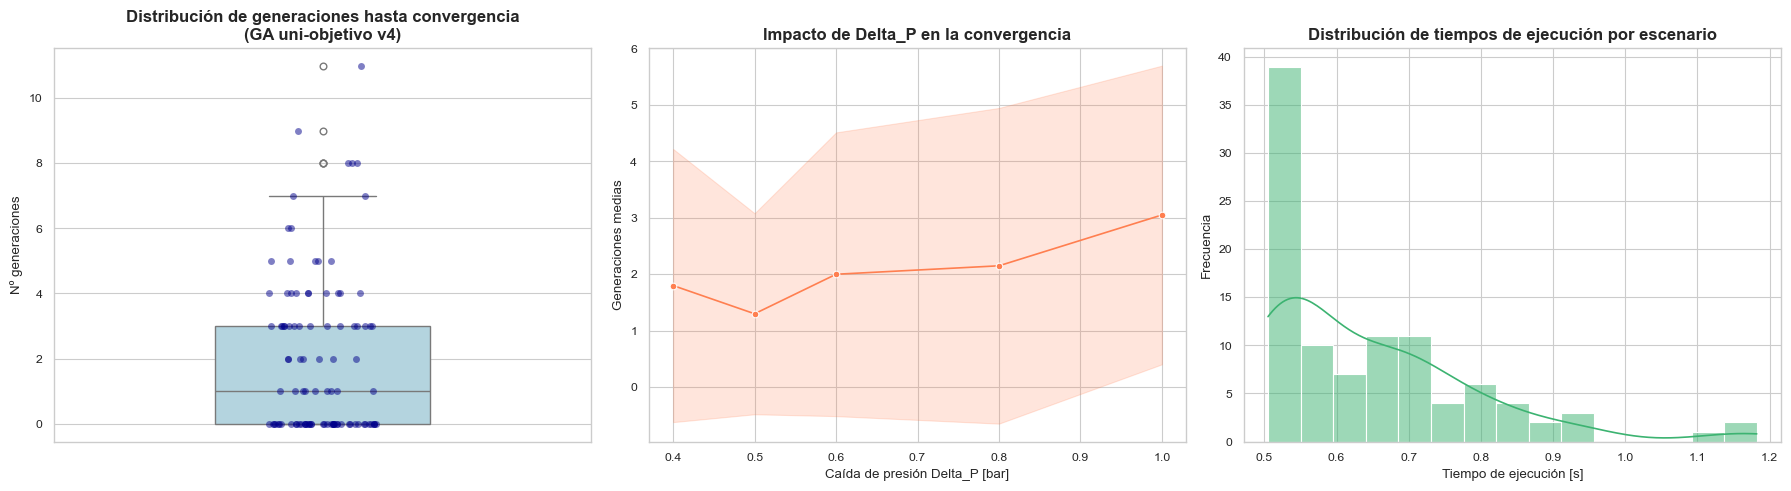

In [53]:
# ==============================================================================
# VISUALIZACIÓN Y ANÁLISIS ESTADÍSTICO DE LA CONVERGENCIA
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de generaciones necesarias para converger
sns.boxplot(
    y=df_convergencia['generaciones_convergencia'],
    ax=axes[0],
    color='lightblue',
    width=0.4
)

sns.stripplot(
    y=df_convergencia['generaciones_convergencia'],
    ax=axes[0],
    color='darkblue',
    alpha=0.5,
    jitter=True
)

axes[0].set_title(
    'Distribución de generaciones hasta convergencia\n(GA uni-objetivo v4)',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_ylabel('Nº generaciones')

# 2. Relación entre Delta_P y generaciones de convergencia
sns.lineplot(
    data=df_convergencia,
    x='Delta_P',
    y='generaciones_convergencia',
    marker='o',
    errorbar='sd',
    ax=axes[1],
    color='coral'
)

axes[1].set_title(
    'Impacto de Delta_P en la convergencia',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel('Caída de presión Delta_P [bar]')
axes[1].set_ylabel('Generaciones medias')

# 3. Distribución de tiempos de ejecución
sns.histplot(
    df_convergencia['tiempo_ejecucion_s'],
    kde=True,
    ax=axes[2],
    color='mediumseagreen',
    bins=15
)

axes[2].set_title(
    'Distribución de tiempos de ejecución por escenario',
    fontsize=12,
    fontweight='bold'
)
axes[2].set_xlabel('Tiempo de ejecución [s]')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../../models/artifacts/analisis_convergencia_ga_v4.png', dpi=300)
plt.show()

In [54]:
# ==============================================================================
# REPORTE DE CONCLUSIONES PARA JUSTIFICACIÓN TÉCNICA V4
# ==============================================================================

p90_gen = int(df_convergencia['generaciones_convergencia'].quantile(0.90))
p95_gen = int(df_convergencia['generaciones_convergencia'].quantile(0.95))
p99_gen = int(df_convergencia['generaciones_convergencia'].quantile(0.99))

mean_gen = df_convergencia['generaciones_convergencia'].mean()
median_gen = df_convergencia['generaciones_convergencia'].median()
mean_time = df_convergencia['tiempo_ejecucion_s'].mean()
max_time = df_convergencia['tiempo_ejecucion_s'].max()

n_gen_recomendado = p95_gen + 5

print("\n" + "=" * 80)
print("RESUMEN ESTADÍSTICO PARA JUSTIFICACIÓN TÉCNICA — GA V4")
print("=" * 80)
print(f"Escenarios evaluados:        {len(df_convergencia)}")
print(f"Media de generaciones:       {mean_gen:.1f}")
print(f"Mediana de generaciones:     {median_gen:.0f}")
print(f"Percentil 90:                {p90_gen} generaciones")
print(f"Percentil 95:                {p95_gen} generaciones")
print(f"Percentil 99:                {p99_gen} generaciones")
print(f"Tiempo medio por escenario:  {mean_time:.4f} s")
print(f"Tiempo máximo detectado:     {max_time:.4f} s")
print(f"Factibilidad:                {df_convergencia['factible'].mean() * 100:.2f}%")
print("=" * 80)
print("RECOMENDACIÓN DE ARQUITECTURA PARA PRODUCCIÓN")
print("=" * 80)
print("El análisis se ha ejecutado con la misma arquitectura que optimization_ga_v4:")
print("   - GA uni-objetivo")
print("   - Fitness: min E_consumo / F_flow")
print("   - Selección: selTournament")
print("   - Cruce: cxBlend")
print("   - Mutación: mutGaussian")
print("   - Evolución: custom varOr")
print("   - Elitismo: HallOfFame(1)")
print()
print(f"Según el percentil 95, la convergencia se alcanza antes de la generación {p95_gen}")
print("en la mayoría de los escenarios analizados.")
print()
print(f"Recomendación: fijar n_gen = {n_gen_recomendado}")
print("como margen conservador para la optimización masiva.")
print("=" * 80)


RESUMEN ESTADÍSTICO PARA JUSTIFICACIÓN TÉCNICA — GA V4
Escenarios evaluados:        100
Media de generaciones:       2.1
Mediana de generaciones:     1
Percentil 90:                5 generaciones
Percentil 95:                7 generaciones
Percentil 99:                9 generaciones
Tiempo medio por escenario:  0.6475 s
Tiempo máximo detectado:     1.1821 s
Factibilidad:                100.00%
RECOMENDACIÓN DE ARQUITECTURA PARA PRODUCCIÓN
El análisis se ha ejecutado con la misma arquitectura que optimization_ga_v4:
   - GA uni-objetivo
   - Fitness: min E_consumo / F_flow
   - Selección: selTournament
   - Cruce: cxBlend
   - Mutación: mutGaussian
   - Evolución: custom varOr
   - Elitismo: HallOfFame(1)

Según el percentil 95, la convergencia se alcanza antes de la generación 7
en la mayoría de los escenarios analizados.

Recomendación: fijar n_gen = 12
como margen conservador para la optimización masiva.


## decisión final sobre `n_gen`

Como el percentil 95 es 7, fijariamos el numero de generaciones en 12 para garantizar convergencia. Pondremos n_gen = 15 para redondear y maximizar las posibilidades de enocntrar el setpoint óptimo.

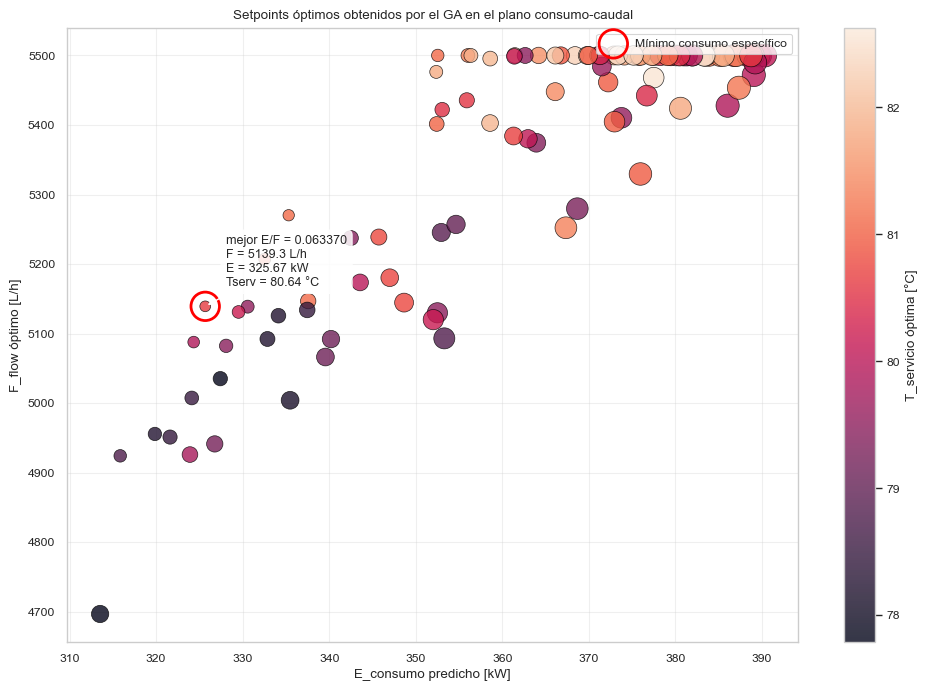

In [55]:
# ==============================================================================
# VISUALIZACIÓN DE SETPOINTS ÓPTIMOS EN EL PLANO CONSUMO-CAUDAL
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------------
# Validación mínima
# ------------------------------------------------------------------------------

required_cols = [
    'E_consumo_pred',
    'F_flow_optimo',
    'T_servicio_optimo',
    'mejor_consumo_esp',
    'T_out_pred',
    'factible'
]

missing_cols = [col for col in required_cols if col not in df_convergencia.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas en df_convergencia: {missing_cols}")

# ------------------------------------------------------------------------------
# Separación entre soluciones factibles y no factibles
# ------------------------------------------------------------------------------

df_plot = df_convergencia.copy()

df_factibles = df_plot[df_plot['factible'] == True]
df_no_factibles = df_plot[df_plot['factible'] == False]

# Tamaño de los puntos proporcional al consumo específico.
# Se normaliza para evitar puntos demasiado pequeños o demasiado grandes.

consumo_esp = df_plot['mejor_consumo_esp'].astype(float)

size_min = 60
size_max = 280

if consumo_esp.max() > consumo_esp.min():
    sizes = size_min + (
        (consumo_esp - consumo_esp.min()) /
        (consumo_esp.max() - consumo_esp.min())
    ) * (size_max - size_min)
else:
    sizes = np.full(len(df_plot), 120)

df_plot['point_size'] = sizes

# ------------------------------------------------------------------------------
# Gráfica principal
# ------------------------------------------------------------------------------

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_factibles['E_consumo_pred'],
    df_factibles['F_flow_optimo'],
    c=df_factibles['T_servicio_optimo'],
    s=df_plot.loc[df_factibles.index, 'point_size'],
    alpha=0.80,
    edgecolors='black',
    linewidths=0.5
)

# Si hubiera soluciones no factibles, se dibujan con marcador distinto
if len(df_no_factibles) > 0:
    plt.scatter(
        df_no_factibles['E_consumo_pred'],
        df_no_factibles['F_flow_optimo'],
        c=df_no_factibles['T_servicio_optimo'],
        s=df_plot.loc[df_no_factibles.index, 'point_size'],
        alpha=0.80,
        marker='x',
        linewidths=1.5,
        label='No factible'
    )

cbar = plt.colorbar(scatter)
cbar.set_label('T_servicio óptima [°C]')

plt.xlabel('E_consumo predicho [kW]')
plt.ylabel('F_flow óptimo [L/h]')
plt.title('Setpoints óptimos obtenidos por el GA en el plano consumo-caudal')

plt.grid(True, alpha=0.3)

# Anotación con el mejor escenario según consumo específico
idx_best = df_plot['mejor_consumo_esp'].idxmin()
best_row = df_plot.loc[idx_best]

plt.scatter(
    best_row['E_consumo_pred'],
    best_row['F_flow_optimo'],
    s=420,
    facecolors='none',
    edgecolors='red',
    linewidths=2.0,
    label='Mínimo consumo específico'
)

plt.annotate(
    f"mejor E/F = {best_row['mejor_consumo_esp']:.6f}\n"
    f"F = {best_row['F_flow_optimo']:.1f} L/h\n"
    f"E = {best_row['E_consumo_pred']:.2f} kW\n"
    f"Tserv = {best_row['T_servicio_optimo']:.2f} °C",
    xy=(best_row['E_consumo_pred'], best_row['F_flow_optimo']),
    xytext=(15, 15),
    textcoords='offset points',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85),
    arrowprops=dict(arrowstyle='->', lw=1)
)

plt.legend()
plt.tight_layout()

plt.savefig('../../models/artifacts/setpoints_optimos_consumo_caudal_ga_v4.png', dpi=300)
plt.show()

In [56]:
# ==============================================================================
# RESUMEN ESTADÍSTICO DE SETPOINTS ÓPTIMOS Y VARIABLES PREDICHAS
# ==============================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# Validación de columnas necesarias
# ------------------------------------------------------------------------------

required_cols = [
    'T_servicio_optimo',
    'F_flow_optimo',
    'E_consumo_pred',
    'T_out_pred',
    'mejor_consumo_esp',
    'factible'
]

missing_cols = [col for col in required_cols if col not in df_convergencia.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas en df_convergencia: {missing_cols}")

# ------------------------------------------------------------------------------
# Selección de soluciones factibles
# ------------------------------------------------------------------------------

df_opt = df_convergencia.copy()

df_factibles = df_opt[df_opt['factible'] == True].copy()

if len(df_factibles) == 0:
    raise ValueError("No hay soluciones factibles en df_convergencia.")

# ------------------------------------------------------------------------------
# Variables a resumir
# ------------------------------------------------------------------------------

variables_resumen = {
    'T_servicio_optimo': 'Temperatura de servicio óptima [°C]',
    'F_flow_optimo': 'Caudal óptimo [L/h]',
    'E_consumo_pred': 'Consumo energético predicho [kW]',
    'T_out_pred': 'Temperatura de salida predicha [°C]',
    'mejor_consumo_esp': 'Consumo específico E/F [kW/(L/h)]'
}

# ------------------------------------------------------------------------------
# Cálculo del resumen estadístico
# ------------------------------------------------------------------------------

resumen_setpoints = []

for col, descripcion in variables_resumen.items():
    serie = df_factibles[col].astype(float)

    resumen_setpoints.append({
        'Variable': descripcion,
        'Media': serie.mean(),
        'Mínimo': serie.min(),
        'Máximo': serie.max(),
        'Desviación típica': serie.std(),
        'Mediana': serie.median()
    })

df_resumen_setpoints = pd.DataFrame(resumen_setpoints)

# ------------------------------------------------------------------------------
# Formato de salida
# ------------------------------------------------------------------------------

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("=" * 90)
print("RESUMEN ESTADÍSTICO DE LOS SETPOINTS ÓPTIMOS DEL GA")
print("=" * 90)
print(f"Número total de instancias evaluadas: {len(df_opt)}")
print(f"Número de soluciones factibles:       {len(df_factibles)}")
print(f"Número de soluciones no factibles:    {len(df_opt) - len(df_factibles)}")
print("=" * 90)

display(df_resumen_setpoints)

# ------------------------------------------------------------------------------
# Mejor solución global según consumo específico
# ------------------------------------------------------------------------------

idx_best = df_factibles['mejor_consumo_esp'].idxmin()
best_row = df_factibles.loc[idx_best]

print("\n" + "=" * 90)
print("MEJOR SETPOINT GLOBAL SEGÚN CONSUMO ESPECÍFICO")
print("=" * 90)
print(f"Índice de la instancia:                  {idx_best}")
print(f"T_servicio óptima [°C]:                  {best_row['T_servicio_optimo']:.6f}")
print(f"F_flow óptimo [L/h]:                     {best_row['F_flow_optimo']:.6f}")
print(f"E_consumo predicho [kW]:                 {best_row['E_consumo_pred']:.6f}")
print(f"T_out predicha [°C]:                     {best_row['T_out_pred']:.6f}")
print(f"Consumo específico E/F [kW/(L/h)]:       {best_row['mejor_consumo_esp']:.8f}")
print("=" * 90)

RESUMEN ESTADÍSTICO DE LOS SETPOINTS ÓPTIMOS DEL GA
Número total de instancias evaluadas: 100
Número de soluciones factibles:       100
Número de soluciones no factibles:    0


,Variable,Media,Mínimo,Máximo,Desviación típica,Mediana
0,Temperatura de servicio óptima [°C],80.569800,77.790000,82.630000,1.243161,80.690000
1,Caudal óptimo [L/h],5349.965700,4696.880000,5500.000000,194.935676,5464.810000
2,Consumo energético predicho [kW],361.583480,313.526800,390.363800,21.269808,366.442750
3,Temperatura de salida predicha [°C],72.300800,72.300000,72.320000,0.003387,72.300000
4,Consumo específico E/F [kW/(L/h)],0.067548,0.063370,0.071122,0.002167,0.067498



MEJOR SETPOINT GLOBAL SEGÚN CONSUMO ESPECÍFICO
Índice de la instancia:                  79
T_servicio óptima [°C]:                  80.640000
F_flow óptimo [L/h]:                     5139.260000
E_consumo predicho [kW]:                 325.673400
T_out predicha [°C]:                     72.300000
Consumo específico E/F [kW/(L/h)]:       0.06337000
